# ASSIGNMENT 1
## Understanding Generative and Discriminative Models Using MNIST

### Objective

The objective of this assignment is to understand the difference between discriminative and generative models using handwritten MNIST digit images. Only the digits 0 and 1 are selected for this experiment.

A Logistic Regression model is used as the discriminative model to classify images as either 0 or 1. A simple Autoencoder is used as the generative model to learn patterns in the digit images and reconstruct similar examples.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [21]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [22]:
# Select only digits 0 and 1
train_filter = (y_train == 0) | (y_train == 1)
test_filter = (y_test == 0) | (y_test == 1)

X_train_01 = X_train[train_filter]
y_train_01 = y_train[train_filter]

X_test_01 = X_test[test_filter]
y_test_01 = y_test[test_filter]

print("Training images:", X_train_01.shape)
print("Testing images:", X_test_01.shape)

Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)


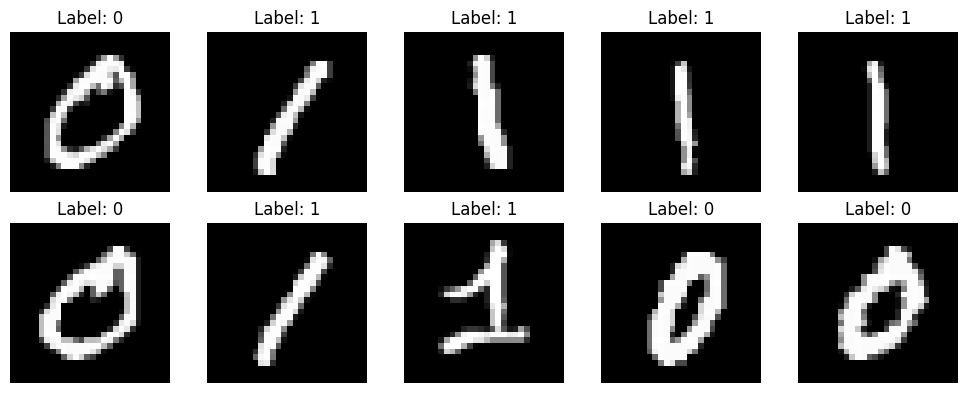

In [23]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_01[i], cmap="gray")
    plt.title(f"Label: {y_train_01[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
X_train_01 = X_train_01.astype("float32") / 255.0
X_test_01 = X_test_01.astype("float32") / 255.0

In [25]:
X_train_lr = X_train_01.reshape(X_train_01.shape[0], -1)
X_test_lr = X_test_01.reshape(X_test_01.shape[0], -1)

print(X_train_lr.shape)
print(X_test_lr.shape)

(12665, 784)
(2115, 784)


In [26]:
# Create Logistic Regression model
model_lr = LogisticRegression(max_iter=1000)

# Train model
model_lr.fit(X_train_lr, y_train_01)

print("Model training completed.")

Model training completed.


In [27]:
y_pred = model_lr.predict(X_test_lr)

accuracy = accuracy_score(y_test_01, y_pred)

print("Discriminative Model Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test_01, y_pred))

Discriminative Model Accuracy: 0.9995271867612293

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



## Discriminative Model Results

The Logistic Regression model was trained to distinguish between handwritten digits 0 and 1.

The model achieved an accuracy of approximately **99.95%** on the test dataset.

This shows that the model successfully learned the differences between the two digit classes and learned a **decision boundary** that separates digit 0 from digit 1.


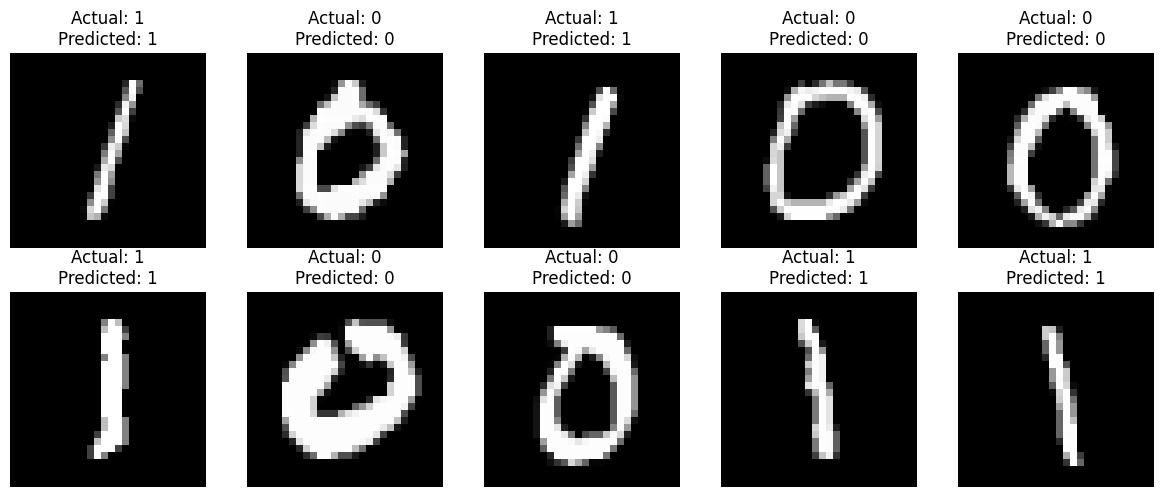

In [28]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(
        f"Actual: {y_test_01[i]}\nPredicted: {y_pred[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
X_auto = np.concatenate([X_train_01, X_test_01], axis=0)

print("Autoencoder dataset:", X_auto.shape)

Autoencoder dataset: (14780, 28, 28)


In [30]:
autoencoder = Sequential([

    # Encoder
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(32, activation="relu"),

    # Decoder
    Dense(128, activation="relu"),
    Dense(784, activation="sigmoid"),
    Reshape((28, 28))
])

autoencoder.compile(
    optimizer=Adam(),
    loss="binary_crossentropy"
)

autoencoder.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = autoencoder.fit(
    X_auto,
    X_auto,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2484 - val_loss: 0.1397
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1259 - val_loss: 0.1148
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1102 - val_loss: 0.1031
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0986 - val_loss: 0.0926
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0910 - val_loss: 0.0876
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0867 - val_loss: 0.0838
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0832 - val_loss: 0.0810
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0805 - val_loss: 0.0785
Epoch 9/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0782 - val_loss: 0.0770
Epoch 10/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0767 - val_loss: 0.0756


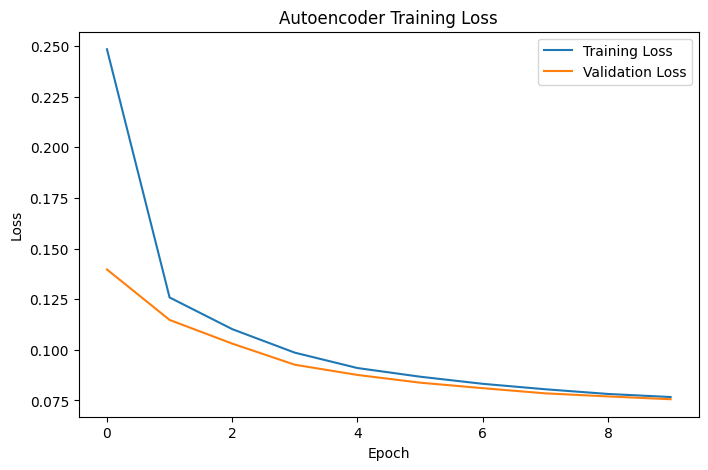

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")

plt.legend()
plt.show()

In [33]:
reconstructed = autoencoder.predict(X_test_01[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


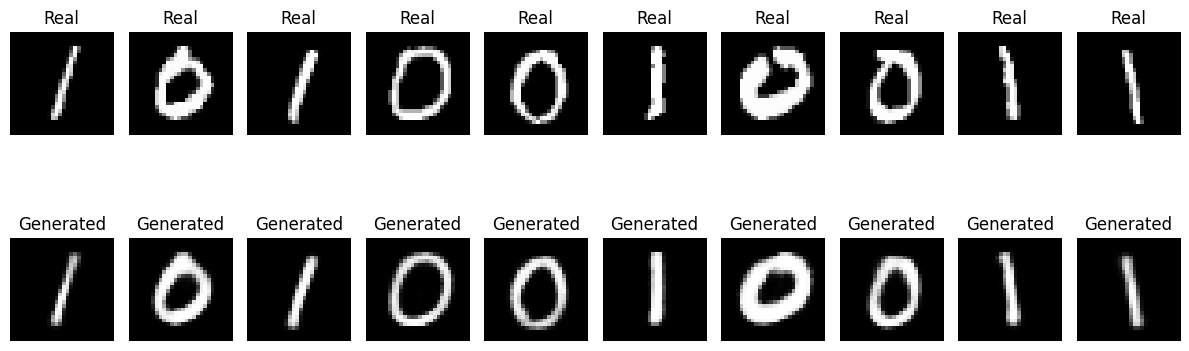

In [34]:
plt.figure(figsize=(12, 5))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title("Real")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i], cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# Take some real images
sample_images = X_test_01[:10].copy()

# Add small random noise
noise = np.random.normal(0, 0.15, sample_images.shape)

noisy_images = sample_images + noise
noisy_images = np.clip(noisy_images, 0, 1)

# Generate reconstructed images
generated_images = autoencoder.predict(noisy_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


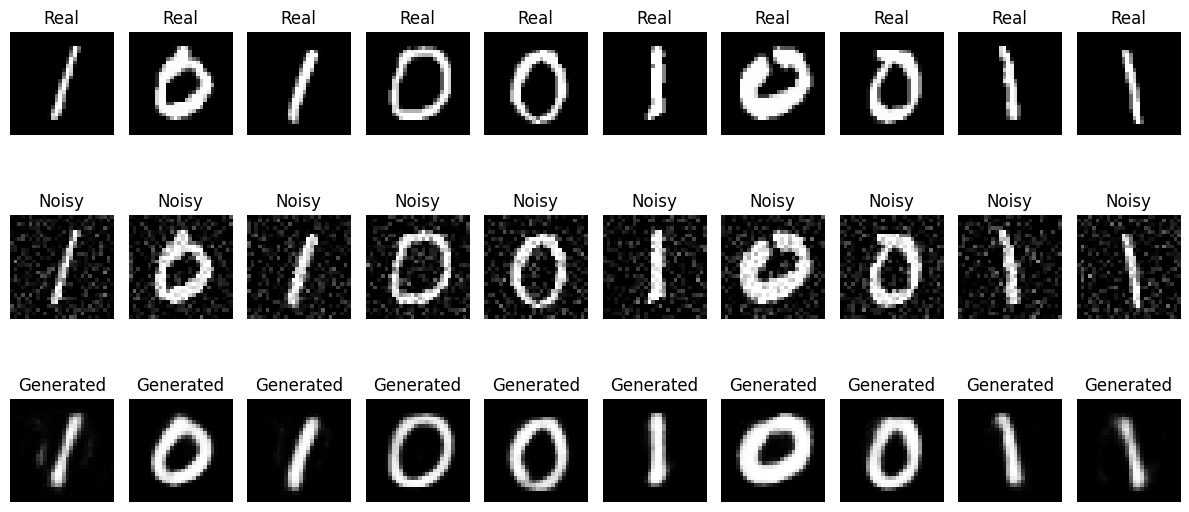

In [36]:
plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(3, 10, i + 1)
    plt.imshow(sample_images[i], cmap="gray")
    plt.title("Real")
    plt.axis("off")

    plt.subplot(3, 10, i + 11)
    plt.imshow(noisy_images[i], cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, 10, i + 21)
    plt.imshow(generated_images[i], cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

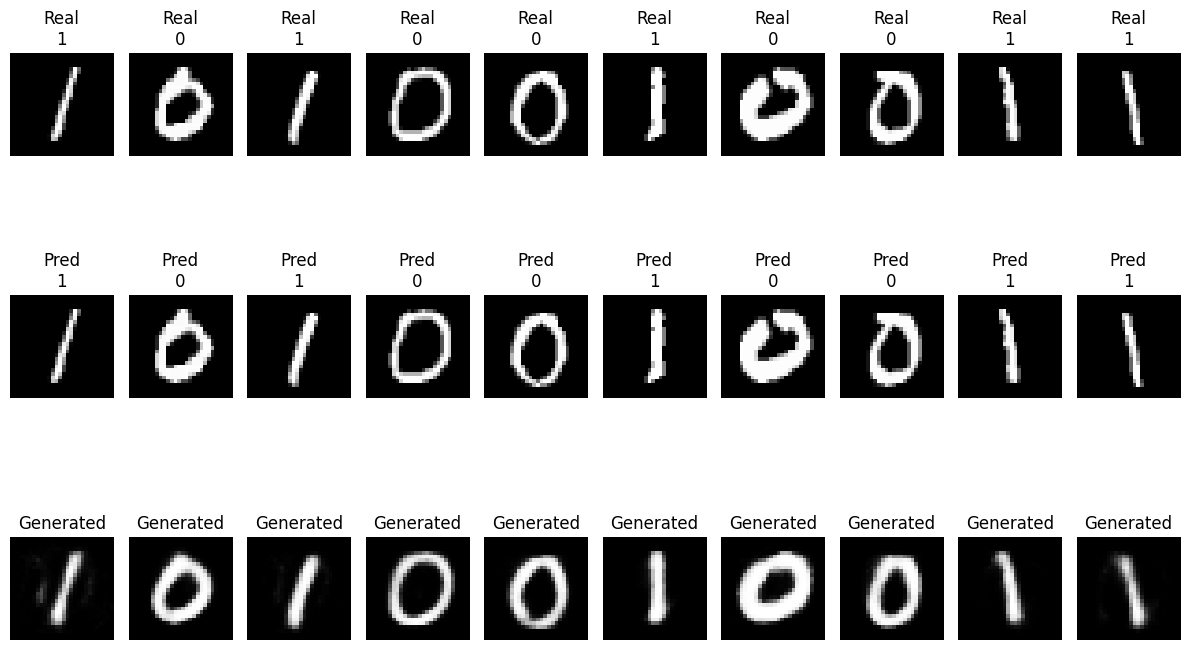

In [37]:
plt.figure(figsize=(12, 8))

for i in range(10):

    # Real
    plt.subplot(3, 10, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(f"Real\n{y_test_01[i]}")
    plt.axis("off")

    # Prediction
    plt.subplot(3, 10, i + 11)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(f"Pred\n{y_pred[i]}")
    plt.axis("off")

    # Generated
    plt.subplot(3, 10, i + 21)
    plt.imshow(generated_images[i], cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

## New Digit-Like Examples from the Learned Latent Representation

The Autoencoder learns a compressed latent representation of the handwritten digits. To demonstrate generation beyond direct reconstruction, we slightly perturb latent representations learned from real images and pass them through the decoder. The resulting images are new digit-like variations based on patterns learned by the Autoencoder.


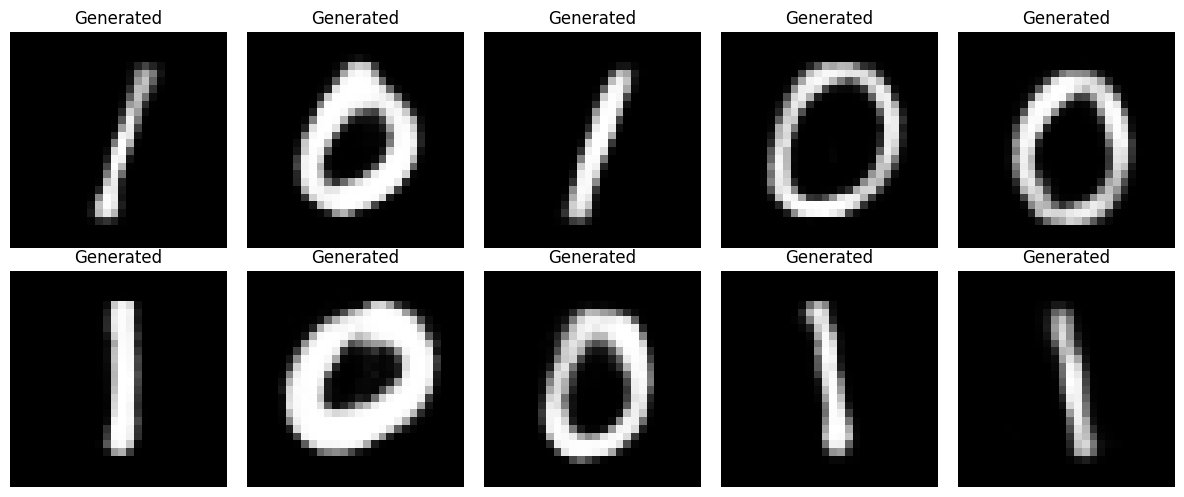

In [38]:
# Use the trained Autoencoder's encoder and decoder parts
encoder = Sequential(autoencoder.layers[:3])
decoder = Sequential(autoencoder.layers[3:])

# Encode real test images into the learned latent space
latent_vectors = encoder.predict(X_test_01[:20], verbose=0)

# Slightly perturb the latent representations
new_latent_vectors = latent_vectors + np.random.normal(
    0, 0.5, latent_vectors.shape
)

# Decode the modified latent representations
new_images = decoder.predict(new_latent_vectors, verbose=0)

# Display new digit-like examples
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(new_images[i], cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Discriminative vs Generative Model

| Aspect | Discriminative Model | Generative Model |
|---|---|---|
| Model Used | Logistic Regression | Autoencoder |
| Main Purpose | Classify 0 and 1 | Learn and reconstruct digit patterns |
| Output | Class label (0 or 1) | Reconstructed/generated image |
| Learning Focus | Decision boundary | Data patterns and representation |
| Labels | Required | Not required |

## Written Reflection

The discriminative model learned the differences between handwritten 0 and 1 images and used them to classify new images. The generative model learned the important patterns and structure of the digit images and used them to reconstruct similar examples. The main difference is that the discriminative model focuses on learning a decision boundary between classes, while the generative model focuses on learning patterns in the data. The discriminative model predicts the class of an image, whereas the generative model reconstructs or generates images similar to the data it learned from.

## Conclusion

In this assignment, Logistic Regression was used as a discriminative model to classify handwritten digits 0 and 1. The model achieved an accuracy of approximately 99.95%. A simple Autoencoder was also trained to learn the patterns of the digit images and reconstruct similar examples. This experiment demonstrates the difference between learning a decision boundary for classification and learning the underlying patterns of the data.
